base model 1

In [1]:
# =========================================================
# FULL CODING — BASE LSTM + CV + SAVE FOR STREAMLIT
# =========================================================

# ======================
# IMPORT
# ======================
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc
)

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# ======================
# OUTPUT DIRECTORY
# ======================
output_dir = "/content/drive/MyDrive/Tesis/Fix FE CV/LSTM/Base Model/"
os.makedirs(output_dir, exist_ok=True)
print("Output disimpan di:", output_dir)

Output disimpan di: /content/drive/MyDrive/Tesis/Fix FE CV/LSTM/Base Model/


In [4]:
# ======================
# LOAD DATASET
# ======================
file_path = "/content/drive/MyDrive/Tesis/Eksperimen/Dataset/Data Gabungan/fix_data_gabungan_fe_tambahan_2.csv"
df = pd.read_csv(file_path)

TARGET = "Gallstone Status"
X = df.drop(columns=[TARGET]).values
y = df[TARGET].values

print("\nDistribusi kelas:")
print(pd.Series(y).value_counts())


Distribusi kelas:
0    452
1    161
Name: count, dtype: int64


In [5]:
# ======================
# STRATIFIED K-FOLD
# ======================
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

metrics_cv = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": []
}

y_true_all, y_pred_all, y_proba_all = [], [], []
history_first_fold = None
last_scaler = None
last_model = None

In [6]:
# ======================
# BUILD BASE LSTM
# ======================
def build_lstm():
    model = Sequential()
    model.add(LSTM(
        units=64,
        input_shape=(1, n_features),
        return_sequences=False
    ))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation="relu"))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [7]:
# ======================
# TRAINING PER FOLD
# ======================
fold = 1

for train_idx, val_idx in kfold.split(X, y):
    print(f"\n===== Fold {fold} =====")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    last_scaler = scaler

    # SMOTE hanya training
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    # Global n_features
    n_features = X_train.shape[1]

    # Reshape untuk LSTM
    X_train_lstm = X_train.reshape((-1, 1, n_features))
    X_val_lstm   = X_val.reshape((-1, 1, n_features))

    # Build model
    model = build_lstm()

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_lstm, y_train,
        validation_data=(X_val_lstm, y_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    if fold == 1:
        history_first_fold = history

    last_model = model

    # Prediction
    y_val_proba = model.predict(X_val_lstm).ravel()
    y_val_pred  = (y_val_proba >= 0.5).astype(int)

    # Metrics
    metrics_cv["accuracy"].append(accuracy_score(y_val, y_val_pred))
    metrics_cv["precision"].append(precision_score(y_val, y_val_pred))
    metrics_cv["recall"].append(recall_score(y_val, y_val_pred))
    metrics_cv["f1"].append(f1_score(y_val, y_val_pred))
    metrics_cv["roc_auc"].append(roc_auc_score(y_val, y_val_proba))

    y_true_all.extend(y_val)
    y_pred_all.extend(y_val_pred)
    y_proba_all.extend(y_val_proba)

    fold += 1




===== Fold 1 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step

===== Fold 2 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step

===== Fold 3 =====


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step

===== Fold 9 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step

===== Fold 10 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


In [8]:
# ======================
# SAVE MODEL & SCALER
# ======================
last_model.save(os.path.join(output_dir, "lstm_base_model.keras"))
joblib.dump(last_scaler, os.path.join(output_dir, "scaler.pkl"))

print("\nModel & scaler disimpan.")


Model & scaler disimpan.


In [9]:
# ======================
# SAVE CV METRICS
# ======================
metrics_df = pd.DataFrame(metrics_cv)
metrics_df.loc["Mean"] = metrics_df.mean()
metrics_df.loc["Std"]  = metrics_df.std()

display(metrics_df)

metrics_df.to_csv(os.path.join(output_dir, "cv_metrics.csv"))
print("Metrics CV disimpan.")

,accuracy,precision,recall,f1,roc_auc
0,0.854839,0.652174,0.937500,0.769231,0.941576
1,0.774194,0.535714,0.937500,0.681818,0.828804
2,0.725806,0.500000,0.705882,0.585366,0.754248
3,0.721311,0.482759,0.875000,0.622222,0.873611
4,0.721311,0.482759,0.875000,0.622222,0.850000
5,0.688525,0.451613,0.875000,0.595745,0.770833
6,0.786885,0.560000,0.875000,0.682927,0.854167
7,0.786885,0.555556,0.937500,0.697674,0.912500
8,0.737705,0.500000,0.687500,0.578947,0.834722
9,0.737705,0.500000,0.875000,0.636364,0.811111


Metrics CV disimpan.


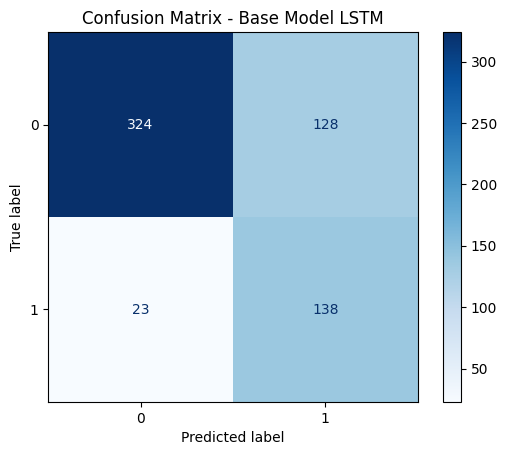

In [10]:
# ======================
# CONFUSION MATRIX
# ======================
cm = confusion_matrix(y_true_all, y_pred_all)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Base Model LSTM")
plt.savefig(os.path.join(output_dir, "confusion_matrix.png"),
            dpi=300, bbox_inches="tight")
plt.show()
plt.close()

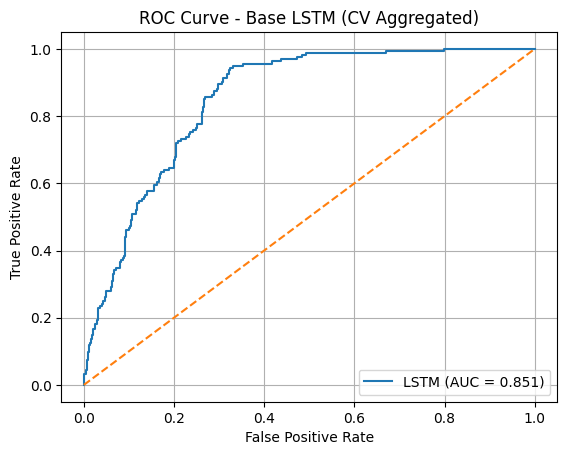

In [11]:
# ======================
# ROC CURVE
# ======================
fpr, tpr, _ = roc_curve(y_true_all, y_proba_all)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"LSTM (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Base LSTM (CV Aggregated)")
plt.legend(loc="lower right")
plt.grid(True)

plt.savefig(os.path.join(output_dir, "roc_curve.png"),
            dpi=300, bbox_inches="tight")
plt.show()
plt.close()

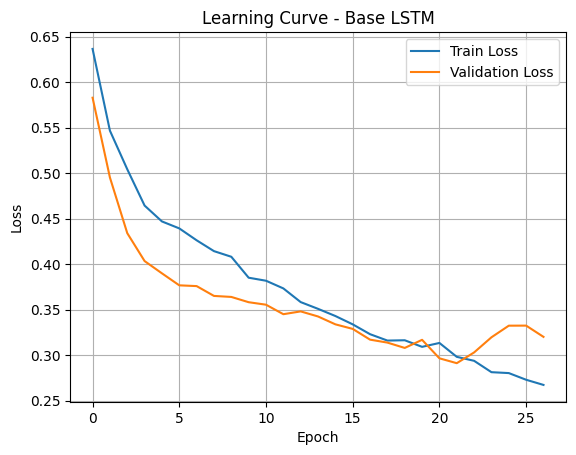

In [12]:
# ======================
# LEARNING CURVE
# ======================
plt.figure()
plt.plot(history_first_fold.history["loss"], label="Train Loss")
plt.plot(history_first_fold.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve - Base LSTM")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(output_dir, "learning_curve.png"),
            dpi=300, bbox_inches="tight")
plt.show()
plt.close()


In [13]:
# ======================
# SAVE METADATA
# ======================
metadata = {
    "model_type": "LSTM Base Model",
    "target": TARGET,
    "task": "Binary Classification",
    "cv": "Stratified 5-Fold",
    "smote": True,
    "scaler": "StandardScaler",
    "epochs": 50,
    "batch_size": 32,
    "optimizer": "Adam",
    "learning_rate": 0.001
}

with open(os.path.join(output_dir, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadata disimpan.")
print("\n=== SEMUA PROSES SELESAI ===")

Metadata disimpan.

=== SEMUA PROSES SELESAI ===


Parameter Tunning

In [14]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [15]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
file_path = "/content/drive/MyDrive/Tesis/Eksperimen/Dataset/Data Gabungan/fix_data_gabungan_fe_tambahan_2.csv"
df = pd.read_csv(file_path)

TARGET = "Gallstone Status"
X = df.drop(columns=[TARGET])
y = df[TARGET].values


In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

np.save(os.path.join(output_dir, "scaler.npy"), X.columns)


In [18]:
n_features = X_scaled.shape[1]

def build_lstm():
    model = Sequential()
    model.add(LSTM(
        units=64,
        input_shape=(1, n_features),
        return_sequences=False
    ))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation="relu"))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [19]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

acc_list, prec_list, rec_list, f1_list, auc_list = [], [], [], [], []
y_true_all, y_pred_all, y_prob_all = [], [], []

history_first_fold = None


In [20]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y), 1):
    print(f"Fold {fold}")

    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    X_train_lstm = X_train.reshape(-1, 1, n_features)
    X_val_lstm = X_val.reshape(-1, 1, n_features)

    model = build_lstm()

    history = model.fit(
        X_train_lstm, y_train,
        validation_data=(X_val_lstm, y_val),
        epochs=50,
        batch_size=32,
        verbose=0
    )

    if fold == 1:
        history_first_fold = history

    y_prob = model.predict(X_val_lstm).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc_list.append(accuracy_score(y_val, y_pred))
    prec_list.append(precision_score(y_val, y_pred))
    rec_list.append(recall_score(y_val, y_pred))
    f1_list.append(f1_score(y_val, y_pred))
    auc_list.append(roc_auc_score(y_val, y_prob))

    y_true_all.extend(y_val)
    y_pred_all.extend(y_pred)
    y_prob_all.extend(y_prob)


Fold 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
Fold 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Fold 3


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
Fold 9


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Fold 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


In [21]:
metrics = {
    "Accuracy": (np.mean(acc_list), np.std(acc_list)),
    "Precision": (np.mean(prec_list), np.std(prec_list)),
    "Recall": (np.mean(rec_list), np.std(rec_list)),
    "F1-Score": (np.mean(f1_list), np.std(f1_list)),
    "ROC-AUC": (np.mean(auc_list), np.std(auc_list))
}

metrics_df = pd.DataFrame(metrics, index=["Mean", "Std"]).T
print("\n===== MEAN CV METRICS =====")
print(metrics_df)

metrics_df.to_csv(os.path.join(output_dir, "mean_cv_metrics.csv"))



===== MEAN CV METRICS =====
               Mean       Std
Accuracy   0.784611  0.038794
Precision  0.587329  0.060228
Recall     0.597059  0.139901
F1-Score   0.587066  0.087753
ROC-AUC    0.848719  0.041593


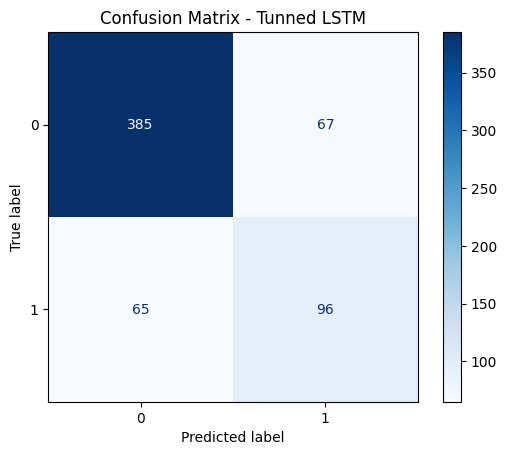

In [22]:
cm = confusion_matrix(y_true_all, y_pred_all)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Tunned LSTM")
plt.savefig(os.path.join(output_dir, "confusion_matrix.png"), dpi=300)
plt.show()


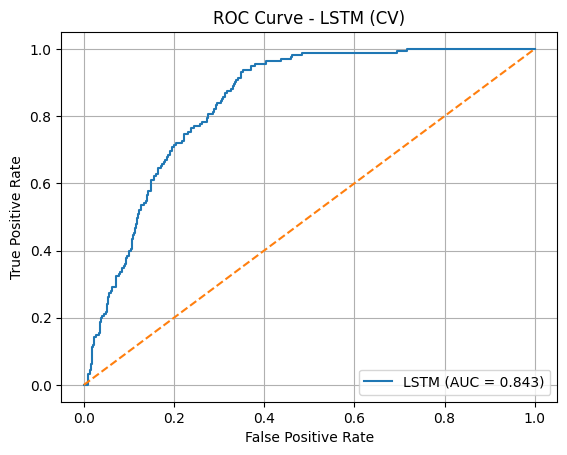

In [23]:
fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"LSTM (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM (CV)")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(output_dir, "roc_curve.png"), dpi=300)
plt.show()


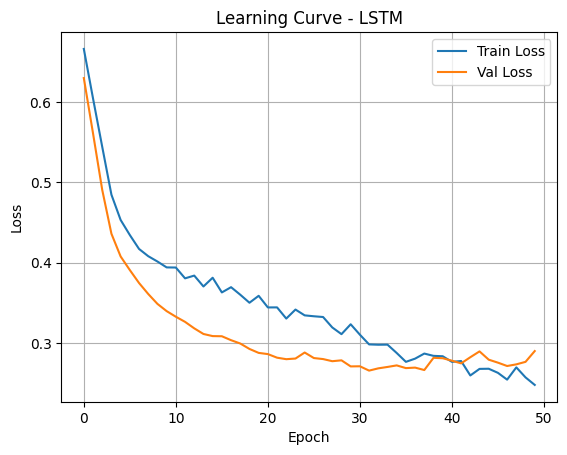

In [24]:
plt.figure()
plt.plot(history_first_fold.history["loss"], label="Train Loss")
plt.plot(history_first_fold.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve - LSTM")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(output_dir, "learning_curve.png"), dpi=300)
plt.show()


In [25]:
model.save(os.path.join(output_dir, "lstm_base_model.keras"))


In [26]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [27]:
output_dir = "/content/drive/MyDrive/Tesis/Fix FE CV/LSTM/Tuned Model/"
os.makedirs(output_dir, exist_ok=True)


In [28]:
file_path = "/content/drive/MyDrive/Tesis/Eksperimen/Dataset/Data Gabungan/fix_data_gabungan_fe_tambahan_2.csv"
df = pd.read_csv(file_path)

TARGET = "Gallstone Status"
X = df.drop(columns=[TARGET])
y = df[TARGET].values


In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_features = X_scaled.shape[1]


In [30]:
param_space = {
    "units": [32, 64, 128],
    "dropout": [0.2, 0.3, 0.4],
    "dense_units": [16, 32, 64],
    "learning_rate": [1e-2, 5e-3, 1e-3],
    "batch_size": [16, 32, 64],
    "epochs": [30, 50]
}

N_ITER = 10   # jumlah random search
N_SPLITS = 10  # CV


In [31]:
def build_lstm(params):
    model = Sequential()
    model.add(LSTM(
        units=params["units"],
        input_shape=(1, n_features),
        return_sequences=False
    ))
    model.add(Dropout(params["dropout"]))
    model.add(Dense(params["dense_units"], activation="relu"))
    model.add(Dropout(params["dropout"]))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=params["learning_rate"]),
        loss="binary_crossentropy"
    )
    return model


In [32]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

best_auc = -1
best_params = None
results = []


In [33]:
for iteration in range(1, N_ITER + 1):
    print(f"\nRandom Search Iteration {iteration}/{N_ITER}")

    params = {k: random.choice(v) for k, v in param_space.items()}
    print("Params:", params)

    auc_list = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y), 1):

        X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        X_train_lstm = X_train.reshape(-1, 1, n_features)
        X_val_lstm = X_val.reshape(-1, 1, n_features)

        model = build_lstm(params)

        model.fit(
            X_train_lstm, y_train,
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            verbose=0
        )

        y_val_prob = model.predict(X_val_lstm).ravel()
        auc_score = roc_auc_score(y_val, y_val_prob)
        auc_list.append(auc_score)

    mean_auc = np.mean(auc_list)
    print(f"Mean ROC-AUC: {mean_auc:.4f}")

    results.append({
        **params,
        "mean_auc": mean_auc
    })

    if mean_auc > best_auc:
        best_auc = mean_auc
        best_params = params



Random Search Iteration 1/10
Params: {'units': 32, 'dropout': 0.4, 'dense_units': 64, 'learning_rate': 0.01, 'batch_size': 32, 'epochs': 30}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
Mean ROC-AUC: 0.8390


In [34]:
results_df = pd.DataFrame(results)
results_df.to_csv(
    os.path.join(output_dir, "random_search_results.csv"),
    index=False
)

with open(os.path.join(output_dir, "best_params.json"), "w") as f:
    json.dump(best_params, f, indent=4)

print("\n===== BEST PARAMETERS =====")
print(best_params)
print(f"Best Mean ROC-AUC: {best_auc:.4f}")



===== BEST PARAMETERS =====
{'units': 128, 'dropout': 0.4, 'dense_units': 64, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 30}
Best Mean ROC-AUC: 0.8516


In [35]:
X_lstm = X_scaled.reshape(-1, 1, n_features)

final_model = build_lstm(best_params)

final_model.fit(
    X_lstm, y,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    verbose=0
)

final_model.save(os.path.join(output_dir, "lstm_best_model.keras"))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


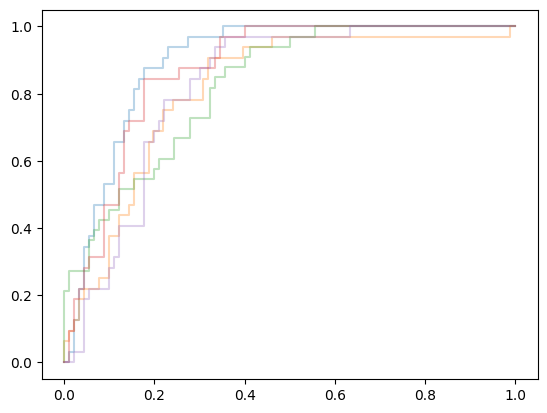

In [36]:
from sklearn.metrics import roc_curve

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure()

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    X_train_lstm = X_train.reshape(-1, 1, n_features)
    X_val_lstm = X_val.reshape(-1, 1, n_features)

    model = build_lstm(best_params)

    model.fit(
        X_train_lstm, y_train,
        epochs=best_params["epochs"],
        batch_size=best_params["batch_size"],
        verbose=0
    )

    y_prob = model.predict(X_val_lstm).ravel()

    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)

    aucs.append(roc_auc)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    plt.plot(fpr, tpr, alpha=0.3, label=f"Fold {fold} (AUC={roc_auc:.3f})")


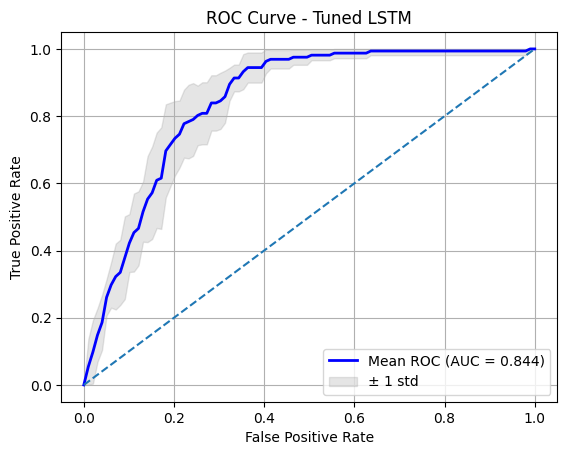

In [37]:
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

plt.plot(
    mean_fpr, mean_tpr,
    color="blue",
    label=f"Mean ROC (AUC = {mean_auc:.3f})",
    lw=2
)

std_tpr = np.std(tprs, axis=0)
tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
tpr_lower = np.maximum(mean_tpr - std_tpr, 0)

plt.fill_between(
    mean_fpr, tpr_lower, tpr_upper,
    color="grey", alpha=0.2, label="± 1 std"
)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned LSTM")
plt.legend(loc="lower right")
plt.grid(True)

plt.savefig(os.path.join(output_dir, "cv_mean_roc.png"), dpi=300)
plt.show()


In [38]:
X_lstm_all = X_scaled.reshape(-1, 1, n_features)

y_prob_all = final_model.predict(X_lstm_all).ravel()
y_pred_all = (y_prob_all >= 0.5).astype(int)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [39]:
acc = accuracy_score(y, y_pred_all)
prec = precision_score(y, y_pred_all)
rec = recall_score(y, y_pred_all)
f1 = f1_score(y, y_pred_all)
roc_auc = roc_auc_score(y, y_prob_all)


In [40]:
print("\n===== BEST LSTM MODEL METRICS =====")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")



===== BEST LSTM MODEL METRICS =====
Accuracy  : 0.8483
Precision : 0.7237
Recall    : 0.6832
F1-Score  : 0.7029
ROC-AUC   : 0.9341


In [41]:
metrics_best = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1-Score": f1,
    "ROC-AUC": roc_auc
}

with open(os.path.join(output_dir, "best_model_metrics.json"), "w") as f:
    json.dump(metrics_best, f, indent=4)

pd.DataFrame(metrics_best, index=["Score"]).T.to_csv(
    os.path.join(output_dir, "best_model_metrics.csv")
)
